# Simulate Rocket

This notebook establishes the baseline flight performance for the reference **Golden Rocket** configuration utilizing high-fidelity 6-DOF simulation physics. By analyzing critical metrics such as apogee, stability margins, and ground range, we define the ground truth targets required to benchmark and validate the subsequent optimization algorithms. The study concludes with a detailed visualization of the flight dynamics, providing both static trajectory profiles and a kinematic replay of the mission to verify physical realism.

In [7]:
import sys
import os

# Setup the path to import modules from the parent directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Add parent directory to sys.path to access simulation modules
sys.path.append(parent_dir)
#print(f"Current working directory: {os.getcwd()}")

import numpy as np
import matplotlib.pyplot as plt
from rocketpy import Environment, Flight

# Import the custom RocketFactory module
# Ensure 'simulation/rocket_factory.py' exists relative to the parent directory
try:
    from simulation.rocket_factory import RocketFactory
    print("RocketFactory module imported successfully.")
except ImportError:
    print("ERROR: Could not find 'simulation/rocket_factory.py'.") 
    print("Ensure the simulation directory and factory file exist.")

RocketFactory module imported successfully.


In [2]:
import datetime

# Initialize Environment (Spaceport America coordinates)
env = Environment(
    latitude=32.990254,
    longitude=-106.974998,
    elevation=1400 # Meters above sea level
)

# Set date to tomorrow at noon
tomorrow = datetime.date.today() + datetime.timedelta(days=1)
env.set_date((tomorrow.year, tomorrow.month, tomorrow.day, 12)) 

# Apply Standard Atmosphere model
env.set_atmospheric_model(type="standard_atmosphere")

In [3]:
import yaml

# Load configuration from YAML file
config_path = "../config/missile_constraints.yaml"

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

# Extract relevant sections
bounds = config['design_variables']
targets_single = config['single_trajectory_target']
golden_rocket_params = config['golden_rocket']

print("Configuration loaded.")
print(f"Golden Rocket Impulse: {golden_rocket_params['total_impulse']} Ns")

Configuration loaded.
Golden Rocket Impulse: 3200.0 Ns


In [4]:
# Instantiate the factory
factory = RocketFactory()

try:
    # Create the rocket object using the golden parameters
    rocket = factory.create_rocket(golden_rocket_params)
    
    print("Rocket assembled successfully.")
    print(f"Takeoff Mass: {rocket.mass:.2f} kg")
    print(f"Total Length: {golden_rocket_params['body_length'] + golden_rocket_params['nose_length']:.2f} m")
    
    # Check Static Stability Margin
    # Normalized by diameter; value should be > 1.0 for stable flight
    static_margin = rocket.static_margin(0)
    print(f"Static Margin:  {static_margin:.2f} calibers")
    
    if static_margin < 0:
        print("WARNING: Rocket is unstable (CP is ahead of CG).")
    elif static_margin < 1.0:
        print("WARNING: Low stability margin.")
    else:
        print("Stability is within acceptable limits.")

except Exception as e:
    print(f"Error during rocket assembly: {e}")

Rocket assembled successfully.
Takeoff Mass: 8.47 kg
Total Length: 2.75 m
Static Margin:  1.50 calibers
Stability is within acceptable limits.


In [5]:
print("Starting 6-DOF flight simulation...")

try:
    # Retrieve launch parameters (rail length and angle) from factory
    launch_cfg = factory.get_launch_parameters(golden_rocket_params)

    # Execute Flight Simulation
    flight = Flight(
        rocket=rocket,
        environment=env,
        rail_length=launch_cfg['rail_length'],
        inclination=launch_cfg['launch_angle'],
        heading=90, # Launch towards East
        terminate_on_apogee=False # Simulate until ground impact
    )
    
    print("Simulation completed successfully.")

except Exception as e:
    print(f"Error during flight simulation: {e}")

Starting 6-DOF flight simulation...
Simulation completed successfully.


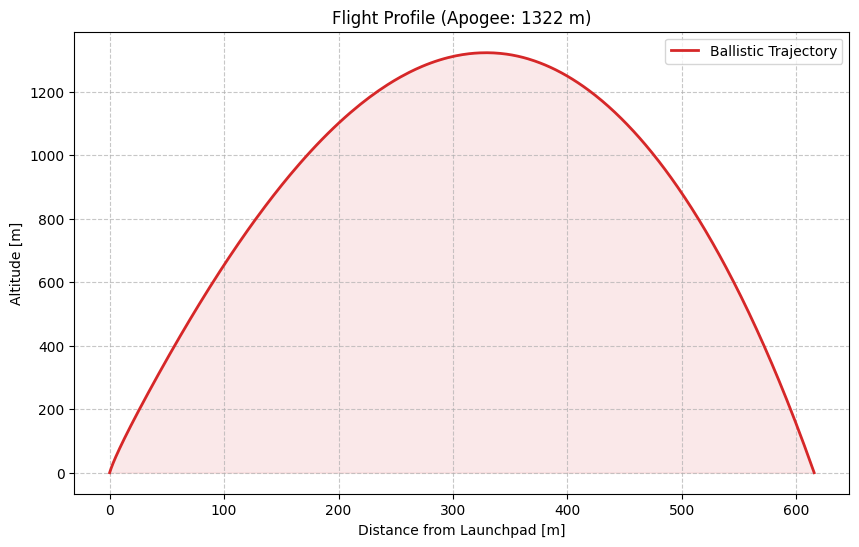

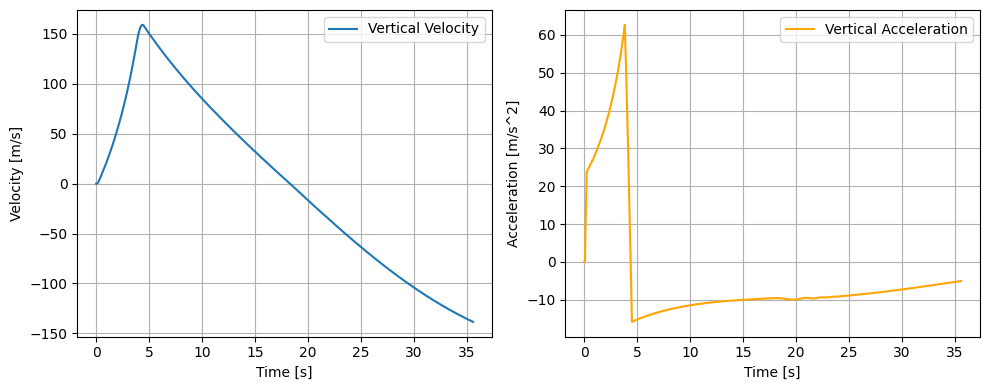

MISSION REPORT

Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 1400.00 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: -0.382 | e1: 0.040 | e2: -0.017 | e3: 0.923
Euler Angles - Spin φ : -45.00° | Nutation θ: -5.00° | Precession ψ: 270.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 1.496 c


Surface Wind Conditions

Frontal Surface Wind Speed: 0.00 m/s
Lateral Surface Wind Speed: 0.00 m/s


Launch Rail

Launch Rail Length: 6.0 m
Launch Rail Inclination: 85.00°
Launch Rail Heading: 90.00°


Rail Departure State

Rail Departure Time: 0.766 s
Rail Departure Velocity: 15.598 m/s
Rail Departure Stability Margin: 1.709 c
Rail Departure Angle of Attack: 0.000°
Rail Departure Thrust-Weight Ratio: 3.747
Rail Departure Reynolds Number: 1.243e+05


Burn out State

Burn out time: 4.550 s
Altitude at burn out: 1728.388 m (ASL) | 328.388 m (AGL)
Rocket speed at burn out: 159.285 m

In [6]:
if 'flight' in locals():
    # --- Data Extraction ---
    # Time array
    t = flight.x[:, 0] 
    
    # Spatial coordinates
    val_x = flight.x[:, 1]
    val_y = flight.y[:, 1]
    val_z = flight.z[:, 1]
    
    # Altitude Above Ground Level (AGL)
    z_agl = val_z - env.elevation
    
    # Ground Range (Euclidean distance from launchpad)
    ground_range = np.sqrt(val_x**2 + val_y**2)
    
    # --- Plot 1: Trajectory Profile ---
    plt.figure(figsize=(10, 6))
    plt.plot(ground_range, z_agl, label='Ballistic Trajectory', color='#d62728', linewidth=2)
    plt.title(f"Flight Profile (Apogee: {flight.apogee - env.elevation:.0f} m)")
    plt.xlabel("Distance from Launchpad [m]")
    plt.ylabel("Altitude [m]")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.fill_between(ground_range, 0, z_agl, color='#d62728', alpha=0.1)
    plt.show()

     # --- Plot 2: Velocity and Acceleration ---
    val_vz = flight.vz[:, 1]
    val_az = flight.az[:, 1]
    
    plt.figure(figsize=(10, 4))
    
    # Velocity Subplot
    plt.subplot(1, 2, 1)
    plt.plot(t, val_vz, label='Vertical Velocity')
    plt.xlabel("Time [s]")
    plt.ylabel("Velocity [m/s]")
    plt.grid(True)
    plt.legend()

    # Acceleration Subplot
    plt.subplot(1, 2, 2)
    plt.plot(t, val_az, label='Vertical Acceleration', color='orange')
    plt.xlabel("Time [s]")
    plt.ylabel("Acceleration [m/s^2]")
    plt.grid(True)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

    # --- Full Report ---
    print("="*40)
    print("MISSION REPORT")
    print("="*40)
    
    flight.info()

In [13]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# ==========================================
# 1. DATA CONFIGURATION & PRE-PROCESSING
# ==========================================

# Downsampling factor: RocketPy generates high-resolution data (thousands of steps).
# We skip frames to ensure the animation renders reasonably fast in the notebook.
skip = 20  

# Extract raw flight data from the Flight object
t_full = flight.x[:, 0]
x_full = flight.x[:, 1]
y_full = flight.y[:, 1]
z_full = flight.z[:, 1] - env.elevation # Altitude Above Ground Level (AGL)
vz_full = flight.vz[:, 1]
az_full = flight.az[:, 1]

# Calculate Ground Range (Euclidean distance from launchpad)
range_full = np.sqrt(x_full**2 + y_full**2)

# Create decimated arrays for the animation frames
t_anim = t_full[::skip]
r_anim = range_full[::skip]
z_anim = z_full[::skip]
v_anim = vz_full[::skip]
a_anim = az_full[::skip]

# ==========================================
# 2. PLOT SETUP
# ==========================================
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Golden Rocket Flight', fontsize=16)

# --- Plot 1: Trajectory (Spatial) ---
ax1.set_xlim(0, np.max(range_full) * 1.1)
ax1.set_ylim(0, np.max(z_full) * 1.1)
ax1.set_xlabel('Range (m)')
ax1.set_ylabel('Altitude AGL (m)')
ax1.set_title('Trajectory')
ax1.grid(True)
line1, = ax1.plot([], [], 'b-', lw=1.5) # Flight path trail
point1, = ax1.plot([], [], 'ro')       # Current rocket position

# --- Plot 2: Vertical Velocity (Kinematics) ---
ax2.set_xlim(0, np.max(t_full))
ax2.set_ylim(np.min(vz_full)*1.1, np.max(vz_full) * 1.1)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Velocity Z (m/s)')
ax2.set_title('Vertical Velocity')
ax2.grid(True)
line2, = ax2.plot([], [], 'g-', lw=1.5)
point2, = ax2.plot([], [], 'go')

# --- Plot 3: Vertical Acceleration (Dynamics) ---
ax3.set_xlim(0, np.max(t_full))
ax3.set_ylim(np.min(az_full)*1.1, np.max(az_full) * 1.1)
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Acc Z (m/s^2)')
ax3.set_title('Vertical Acceleration')
ax3.grid(True)
line3, = ax3.plot([], [], 'm-', lw=1.5)
point3, = ax3.plot([], [], 'mo')

# Time indicator text overlay
time_text = ax1.text(0.05, 0.9, '', transform=ax1.transAxes)

# ==========================================
# 3. FRAME UPDATE FUNCTION
# ==========================================
def update(frame):
    """
    Callback function required by FuncAnimation.
    Updates data for lines and points at every frame step.
    
    Args:
        frame (int): The index of the current frame in the decimated arrays.
        
    Returns:
        tuple: Updated matplotlib artists.
    """
    # Update Trajectory
    line1.set_data(r_anim[:frame], z_anim[:frame])
    point1.set_data([r_anim[frame]], [z_anim[frame]]) # Brackets required for points
    
    # Update Velocity
    line2.set_data(t_anim[:frame], v_anim[:frame])
    point2.set_data([t_anim[frame]], [v_anim[frame]])
    
    # Update Acceleration
    line3.set_data(t_anim[:frame], a_anim[:frame])
    point3.set_data([t_anim[frame]], [a_anim[frame]])
    
    # Update Time Text
    time_text.set_text(f'T = {t_anim[frame]:.2f} s')
    
    return line1, point1, line2, point2, line3, point3

# ==========================================
# 4. ANIMATION GENERATION
# ==========================================
print("Rendering animation... (This may take a moment)")

# Create animation object
ani = FuncAnimation(fig, update, frames=len(t_anim), interval=30, blit=True)
ani.save("../plots/golden_rocket_flight.gif", writer='pillow', fps=30)

# Close static plot to avoid duplication in notebook output
plt.close() 

# Render as HTML5 video
HTML(ani.to_jshtml())

Rendering animation... (This may take a moment)
